TLDR: found out no epochs in NEA are undefined

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.table import Table, Column
import astropy.units as u
from collections import Counter
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
%load_ext autoreload
%autoreload 1
%aimport crossmatching
from crossmatching import Crossmatcher, NEACatalog, SimbadIdSupplier, coord_epoch, allowed_angular_separation, extract_year_from_reflink

# Epoch Analysis: NEA Catalog Coordinate Epochs

The coordinate epoch of each catalog entry determines how far a star may have moved since the HPIC LC4 coordinates were recorded (J2000). `add_coord_epoch_column` assigns an epoch using a 7-level priority rule:

1. Gaia DR3 ID present → **2016.0**
2. Gaia DR2 ID present → **2016.0**
3. `ra_reflink` mentions TICv8/Stassun → **2000.0**
4. `ra_reflink` mentions Hipparcos → **1991.25**
5. `ra_reflink` publication year ≥ 2018 → **2016.0**
6. `ra_reflink` publication year < 2018 → **that year**
7. Default → **2000.0**

This notebook:
- Counts how many entries fall under each epoch value and each assignment rule
- Computes the per-row `allowed_angular_separation` (the 2D search threshold used in `coordinate_crossmatch`)
- Compares threshold distributions across epoch groups

In [ ]:
cm = Crossmatcher(NEACatalog(), SimbadIdSupplier())
cm.load_catalog(from_file="pscomppars.txt")
cat = cm.catalog

epochs = [coord_epoch(rl, dr3, dr2)
          for rl, dr3, dr2 in zip(cat['ra_reflink'], cat['gaia_dr3_id'], cat['gaia_dr2_id'])]
epoch_vals = np.ma.MaskedArray([e if e is not None else 0.0 for e in epochs],
                               mask=[e is None for e in epochs])
cat['coord_epoch'] = epoch_vals

print(f"Catalog rows:   {len(cat):,}")
print(f"Unknown epochs:   {epoch_vals.mask.sum():,}")

## Assign epochs and trace which rule fired

In [ ]:
add_coord_epoch_column = coord_epoch  # old alias used in the rule-tracing loop below
n = len(cat)
rules = np.full(n, "", dtype=object)

gaia_dr3_col = cat["gaia_dr3_id"]
gaia_dr2_col = cat["gaia_dr2_id"]
reflinks_col  = cat["ra_reflink"]

for i in range(n):
    dr3     = gaia_dr3_col[i]
    dr2     = gaia_dr2_col[i]
    reflink = reflinks_col[i]

    if not np.ma.is_masked(dr3) and str(dr3).strip() not in ("", "--", "0"):
        rules[i] = "Gaia DR3 ID"
        continue
    if not np.ma.is_masked(dr2) and str(dr2).strip() not in ("", "--", "0"):
        rules[i] = "Gaia DR2 ID"
        continue

    if np.ma.is_masked(reflink) or not reflink:
        rules[i] = "Default (no reflink)"
        continue

    reflink_upper = reflink.upper()
    if any(k in reflink_upper for k in ("STASSUN", "TICV", "TIC_V")):
        rules[i] = "TICv8 reflink"
        continue
    if any(k in reflink_upper for k in ("HIPPARCOS", "_HIP_", "HIC_")):
        rules[i] = "Hipparcos reflink"
        continue

    pub_year = extract_year_from_reflink(reflink)
    if pub_year is not None:
        rules[i] = "reflink year ≥ 2018 → 2016" if pub_year >= 2018 else f"reflink year {pub_year}"
    else:
        rules[i] = "Default (no year in reflink)"

cat["epoch_rule"] = Column(rules, name="epoch_rule")

from collections import Counter
epoch_counts = Counter(cat["coord_epoch"].data[~cat["coord_epoch"].mask])
rule_counts  = Counter(rules)

print("Epoch value counts:")
for e, c in sorted(epoch_counts.items()):
    print(f"  {e:.2f}  →  {c:,} rows ({100*c/n:.1f}%)")

print("\nAssignment rule counts:")
for r, c in sorted(rule_counts.items(), key=lambda x: -x[1]):
    print(f"  {r:<35s} {c:>5,} ({100*c/n:.1f}%)")

## Bar charts: epoch distribution and assignment rules

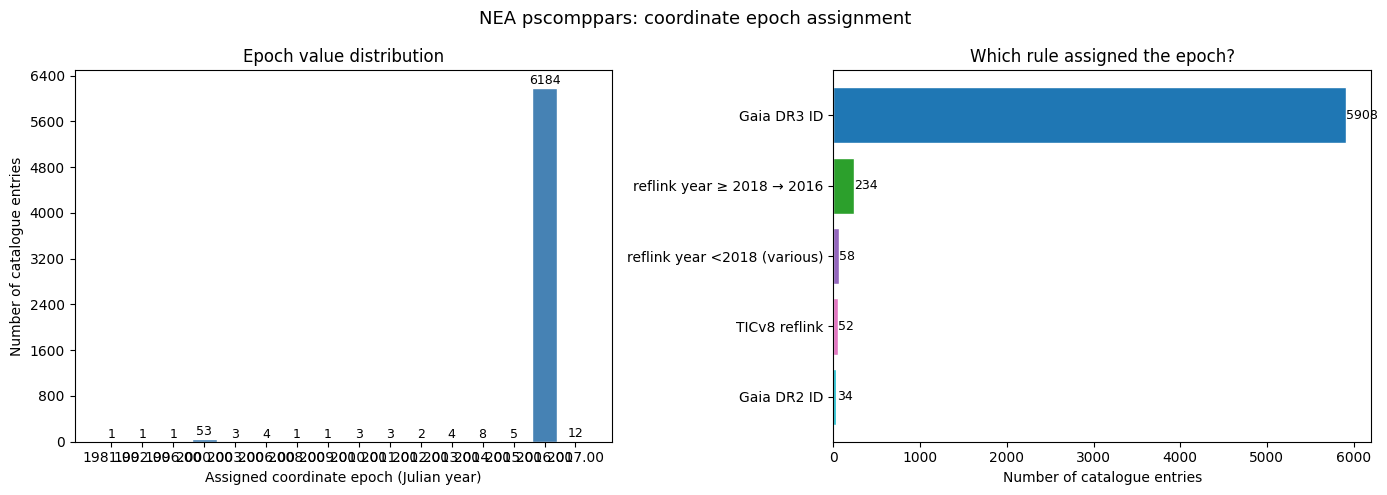

In [35]:
epoch_vals = np.array(cat["coord_epoch"], dtype=float)

# Group all "reflink year YYYY" entries to show a per-year breakdown
year_rules = [(r, c) for r, c in rule_counts.items() if r.startswith("reflink year ") and "≥" not in r]
year_rules.sort()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: epoch value distribution ───────────────────────────────────────────
ax = axes[0]
sorted_epochs = sorted(epoch_counts.items())
labels = [f"{e:.2f}" for e, _ in sorted_epochs]
values = [c for _, c in sorted_epochs]
bars = ax.bar(labels, values, color="steelblue", edgecolor="white")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(v), ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Assigned coordinate epoch (Julian year)")
ax.set_ylabel("Number of catalog entries")
ax.set_title("Epoch value distribution")
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# ── Right: assignment rule breakdown ─────────────────────────────────────────
ax2 = axes[1]
# Aggregate rare per-year rules into a single group for readability
rule_groups = {}
for r, c in rule_counts.items():
    if r.startswith("reflink year ") and "≥" not in r:
        rule_groups["reflink year <2018 (various)"] = rule_groups.get("reflink year <2018 (various)", 0) + c
    else:
        rule_groups[r] = c
rule_groups_sorted = sorted(rule_groups.items(), key=lambda x: -x[1])
r_labels = [r for r, _ in rule_groups_sorted]
r_values = [c for _, c in rule_groups_sorted]
colors = plt.cm.tab10(np.linspace(0, 0.9, len(r_labels)))
bars2 = ax2.barh(r_labels, r_values, color=colors, edgecolor="white")
for bar, v in zip(bars2, r_values):
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(v), ha="left", va="center", fontsize=9)
ax2.set_xlabel("Number of catalog entries")
ax2.set_title("Which rule assigned the epoch?")
ax2.invert_yaxis()

plt.suptitle("NEA pscomppars: coordinate epoch assignment", fontsize=13)
plt.tight_layout()
plt.show()

## Compute allowed 2D separation per catalog entry

`allowed_angular_separation` gives the search cone used during `coordinate_crossmatch`. The threshold is:

```
allowed = (pm + pm_err) × |epoch − 2000| + minimum_floor
```

where `minimum_floor = coordinate_search_radius = 10"` by default.

In [36]:
pm_arcsec    = cat["sy_pm"].filled(0)    / 1000   # mas/yr → arcsec/yr
pmerr_arcsec = cat["sy_pmerr1"].filled(0) / 1000  # mas/yr → arcsec/yr
epochs       = np.array(cat["coord_epoch"], dtype=float)

# Match the floor used in coordinate_crossmatch
floor = cm.coordinate_search_radius  # 10 arcsec by default

allowed_sep = allowed_angular_separation(
    pm_arcsec, pmerr_arcsec, epochs, minimum=floor
)  # Quantity in arcsec

# PM contribution only (no floor), for decomposition
pm_contribution = allowed_angular_separation(
    pm_arcsec, pmerr_arcsec, epochs, minimum=0*u.arcsec
)

sep_arcsec = allowed_sep.to(u.arcsec).value
pm_contrib_arcsec = pm_contribution.to(u.arcsec).value

print(f"Allowed 2D separation statistics (arcsec):")
print(f"  median:  {np.median(sep_arcsec):.2f}")
print(f"  mean:    {np.mean(sep_arcsec):.2f}")
print(f"  max:     {np.max(sep_arcsec):.2f}  → {cat['hostname'][np.argmax(sep_arcsec)]}")
print(f"  > 100\":  {(sep_arcsec > 100).sum():,} entries")
print(f"  = floor: {(sep_arcsec == floor.to(u.arcsec).value).sum():,} entries (PM term = 0)")

Allowed 2D separation statistics (arcsec):
  median:  10.29
  mean:    11.70
  max:     176.30  → Barnard's star
  > 100":  9 entries
  = floor: 352 entries (PM term = 0)


## Distribution of allowed separation, broken down by epoch

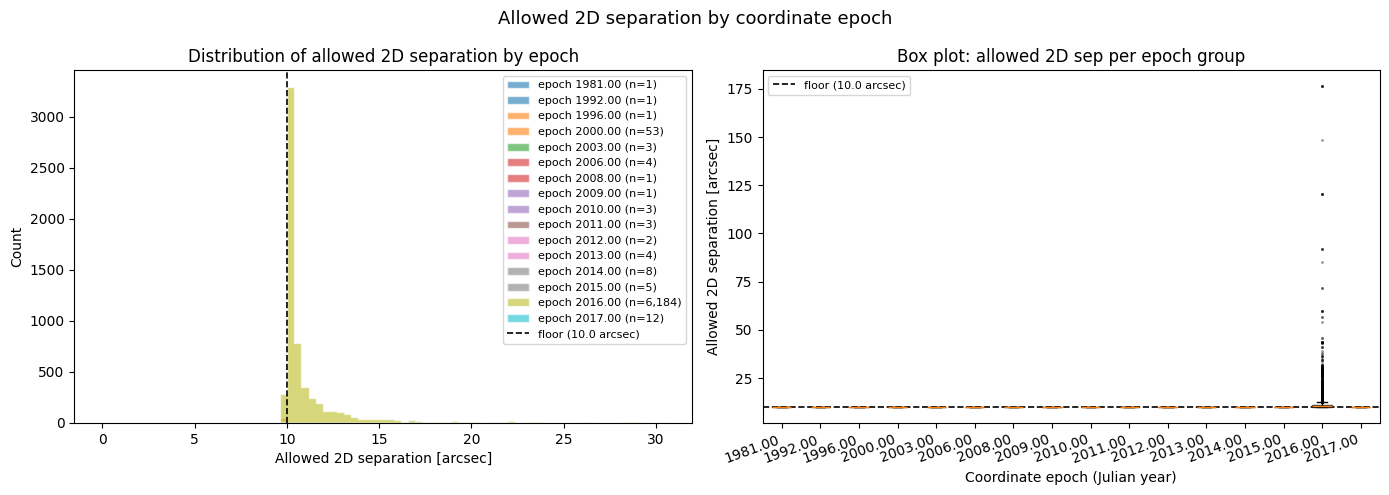

In [37]:
# Unique epoch values present
unique_epochs = sorted(set(epochs))
colors_by_epoch = {e: c for e, c in zip(unique_epochs, plt.cm.tab10(np.linspace(0, 0.9, len(unique_epochs))))}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: histogram per epoch ─────────────────────────────────────────────────
ax = axes[0]
bins = np.linspace(0, min(np.percentile(sep_arcsec, 99), 500), 80)
for e in unique_epochs:
    mask = epochs == e
    ax.hist(sep_arcsec[mask], bins=bins, alpha=0.6,
            label=f"epoch {e:.2f} (n={mask.sum():,})",
            color=colors_by_epoch[e], histtype="stepfilled", edgecolor="white")
ax.axvline(floor.to(u.arcsec).value, color="black", linestyle="--", lw=1.2, label=f"floor ({floor})")
ax.set_xlabel("Allowed 2D separation [arcsec]")
ax.set_ylabel("Count")
ax.set_title("Distribution of allowed 2D separation by epoch")
ax.legend(fontsize=8)

# ── Right: box plot per epoch ─────────────────────────────────────────────────
ax2 = axes[1]
groups = [sep_arcsec[epochs == e] for e in unique_epochs]
bp = ax2.boxplot(groups, patch_artist=True, notch=False, vert=True,
                 flierprops=dict(marker=".", ms=2, alpha=0.4))
for patch, e in zip(bp["boxes"], unique_epochs):
    patch.set_facecolor(colors_by_epoch[e])
    patch.set_alpha(0.7)
ax2.set_xticks(range(1, len(unique_epochs)+1))
ax2.set_xticklabels([f"{e:.2f}" for e in unique_epochs], rotation=20, ha="right")
ax2.axhline(floor.to(u.arcsec).value, color="black", linestyle="--", lw=1.2, label=f"floor ({floor})")
ax2.set_xlabel("Coordinate epoch (Julian year)")
ax2.set_ylabel("Allowed 2D separation [arcsec]")
ax2.set_title("Box plot: allowed 2D sep per epoch group")
ax2.legend(fontsize=8)

plt.suptitle("Allowed 2D separation by coordinate epoch", fontsize=13)
plt.tight_layout()
plt.show()

## PM contribution vs total threshold

For epoch 2016.0 the time baseline is |2016 − 2000| = 16 yr; for 1991.25 it is ~8.75 yr. The PM term can dominate the floor for high-PM stars.

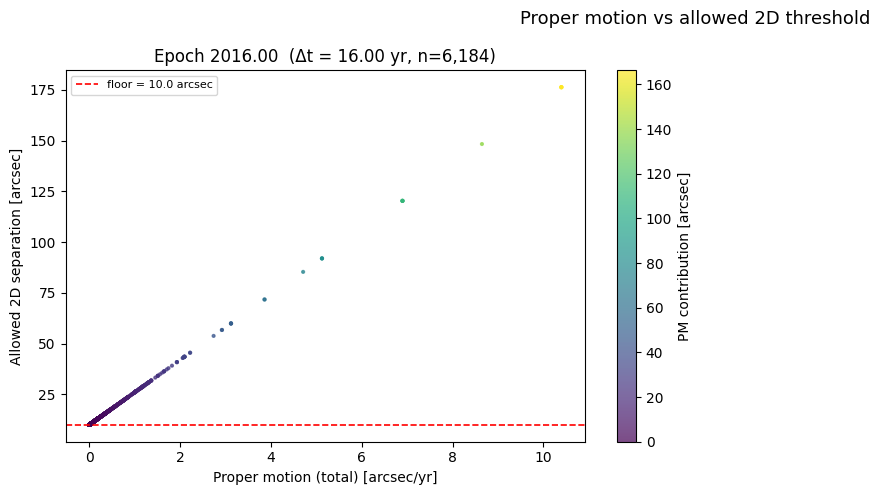

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, e in zip(axes, [2016.0, 1991.25]):
    mask = epochs == e
    if not mask.any():
        ax.set_visible(False)
        continue
    pm_c = pm_contrib_arcsec[mask]
    sep_c = sep_arcsec[mask]
    pm_val = pm_arcsec[mask]

    sc = ax.scatter(pm_val, sep_c, s=4, c=pm_c, cmap="viridis", alpha=0.7)
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("PM contribution [arcsec]")
    ax.axhline(floor.to(u.arcsec).value, color="red", linestyle="--", lw=1.2,
               label=f"floor = {floor}")
    ax.set_xlabel("Proper motion (total) [arcsec/yr]")
    ax.set_ylabel("Allowed 2D separation [arcsec]")
    ax.set_title(f"Epoch {e:.2f}  (Δt = {abs(e-2000):.2f} yr, n={mask.sum():,})")
    ax.legend(fontsize=8)

plt.suptitle("Proper motion vs allowed 2D threshold", fontsize=13)
plt.tight_layout()
plt.show()

## Interactive: per-epoch threshold overview (Plotly)

In [39]:
hostnames = np.array([str(h) for h in cat["hostname"]])

fig = go.Figure()

for e in unique_epochs:
    mask = epochs == e
    x_sorted = np.argsort(sep_arcsec[mask])
    s = sep_arcsec[mask][x_sorted]
    h = hostnames[mask][x_sorted]
    pm = pm_arcsec[mask][x_sorted]
    fig.add_trace(go.Scatter(
        x=list(range(mask.sum())),
        y=s,
        mode="lines",
        name=f"epoch {e:.2f} (n={mask.sum():,})",
        line=dict(shape="hvh"),
        customdata=list(zip(h, pm)),
        hovertemplate="%{customdata[0]}<br>pm=%{customdata[1]:.4f} arcsec/yr<br>allowed=%{y:.2f}\"<extra></extra>",
    ))

fig.add_hline(
    y=floor.to(u.arcsec).value, line_dash="dash", line_color="black",
    annotation_text=f"floor ({floor})", annotation_position="top right"
)

fig.update_layout(
    title="Allowed 2D separation per catalog entry (sorted per epoch group)",
    xaxis_title="Entry index within epoch group (sorted by threshold)",
    yaxis_title="Allowed 2D separation [arcsec]",
    height=500,
    legend=dict(x=0, y=1),
)
fig.show()

## Top-N entries with largest thresholds

These drive the widest search cones and are most likely to produce false positives.

In [40]:
top_n = 20
top_idx = np.argsort(sep_arcsec)[-top_n:][::-1]

import pandas as pd

rows = []
for i in top_idx:
    rows.append({
        "hostname":      str(cat["hostname"][i]),
        "pl_name":       str(cat["pl_name"][i]),
        "epoch":         float(cat["coord_epoch"][i]),
        "epoch_rule":    str(cat["epoch_rule"][i]),
        "pm [arcsec/yr]": round(float(pm_arcsec[i]), 4),
        "pm_err [arcsec/yr]": round(float(pmerr_arcsec[i]), 4),
        "Δt [yr]":       abs(float(cat["coord_epoch"][i]) - 2000),
        'allowed ["]:':  round(float(sep_arcsec[i]), 2),
        'PM contrib ["]:': round(float(pm_contrib_arcsec[i]), 2),
    })

df_top = pd.DataFrame(rows)
print(f"Top {top_n} entries by allowed 2D separation:")
print(df_top.to_string(index=False))

Top 20 entries by allowed 2D separation:
        hostname            pl_name  epoch  epoch_rule  pm [arcsec/yr]  pm_err [arcsec/yr]  Δt [yr]  allowed ["]:  PM contrib ["]:
  Barnard's star          Barnard b 2016.0 Gaia DR3 ID         10.3936              0.0004     16.0        176.30           166.30
  Barnard's star          Barnard e 2016.0 Gaia DR3 ID         10.3936              0.0004     16.0        176.30           166.30
  Barnard's star          Barnard c 2016.0 Gaia DR3 ID         10.3936              0.0004     16.0        176.30           166.30
  Barnard's star          Barnard d 2016.0 Gaia DR3 ID         10.3936              0.0004     16.0        176.30           166.30
         Kapteyn          Kapteyn c 2016.0 Gaia DR3 ID          8.6449              0.0000     16.0        148.32           138.32
          GJ 887           GJ 887 d 2016.0 Gaia DR3 ID          6.8955              0.0001     16.0        120.33           110.33
          GJ 887           GJ 887 c 2016.0

## Cumulative fraction: what fraction of entries have threshold > X arcsec?

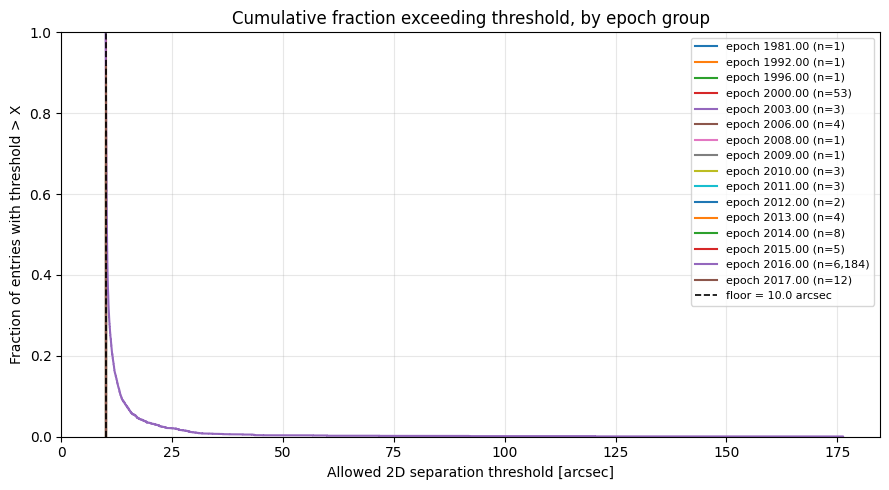

In [41]:
fig, ax = plt.subplots(figsize=(9, 5))

for e in unique_epochs:
    mask = epochs == e
    s = np.sort(sep_arcsec[mask])
    frac_above = 1 - np.arange(1, len(s)+1) / len(s)
    ax.step(s, frac_above, label=f"epoch {e:.2f} (n={mask.sum():,})", where="post")

ax.axvline(floor.to(u.arcsec).value, color="black", linestyle="--", lw=1.2,
           label=f"floor = {floor}")
ax.set_xlabel("Allowed 2D separation threshold [arcsec]")
ax.set_ylabel("Fraction of entries with threshold > X")
ax.set_title("Cumulative fraction exceeding threshold, by epoch group")
ax.legend(fontsize=8)
ax.set_xlim(left=0)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary table: epoch group statistics

In [42]:
rows_summary = []
for e in unique_epochs:
    mask = epochs == e
    s = sep_arcsec[mask]
    at_floor = np.isclose(s, floor.to(u.arcsec).value)
    rows_summary.append({
        "epoch":         f"{e:.2f}",
        "Δt [yr]":       f"{abs(e-2000):.2f}",
        "n entries":     mask.sum(),
        "at floor only": int(at_floor.sum()),
        "% at floor":    f"{100*at_floor.mean():.1f}%",
        'median sep ["]:': f"{np.median(s):.2f}",
        'p95 sep ["]:':   f"{np.percentile(s, 95):.2f}",
        'max sep ["]:':   f"{s.max():.2f}",
    })

df_summary = pd.DataFrame(rows_summary)
print(df_summary.to_string(index=False))

  epoch Δt [yr]  n entries  at floor only % at floor median sep ["]: p95 sep ["]: max sep ["]:
1981.00   19.00          1              1     100.0%           10.00        10.00        10.00
1992.00    8.00          1              1     100.0%           10.00        10.00        10.00
1996.00    4.00          1              1     100.0%           10.00        10.00        10.00
2000.00    0.00         53             53     100.0%           10.00        10.00        10.00
2003.00    3.00          3              3     100.0%           10.00        10.00        10.00
2006.00    6.00          4              4     100.0%           10.00        10.00        10.00
2008.00    8.00          1              1     100.0%           10.00        10.00        10.00
2009.00    9.00          1              1     100.0%           10.00        10.00        10.00
2010.00   10.00          3              3     100.0%           10.00        10.00        10.00
2011.00   11.00          3              3     100.

## Deep-dive: epoch = 2000.0 entries

Epoch 2000.0 covers two fundamentally different situations:

| Sub-group | Why epoch=2000? | Reliable? |
|---|---|---|
| **TICv8 reflink** | Stassun+2019 coordinates are explicitly J2000 | ✓ yes |
| **Default (no reflink / no parseable year)** | We simply don't know | ✗ uncertain |

The defaults are the risk: if the NEA sourced those coordinates from a Gaia-era paper (2018+), the true epoch is ~2016 and we're underestimating Δt by 16 years. For high-PM stars this leads to a search cone that's too narrow.

In [43]:
mask_2000 = epochs == 2000.0

# Split by the rule that assigned 2000.0
rule_arr = np.array(cat["epoch_rule"], dtype=object)

mask_ticv8   = mask_2000 & np.array([r == "TICv8 reflink"           for r in rule_arr])
mask_no_ref  = mask_2000 & np.array([r == "Default (no reflink)"    for r in rule_arr])
mask_no_year = mask_2000 & np.array([r == "Default (no year in reflink)" for r in rule_arr])
mask_default = mask_no_ref | mask_no_year   # all genuinely uncertain entries

print(f"All epoch=2000.0 entries:         {mask_2000.sum():>5,}")
print(f"  TICv8 reflink (intentional):    {mask_ticv8.sum():>5,}  ({100*mask_ticv8.sum()/mask_2000.sum():.1f}%)")
print(f"  Default – no reflink:           {mask_no_ref.sum():>5,}  ({100*mask_no_ref.sum()/mask_2000.sum():.1f}%)")
print(f"  Default – no year in reflink:   {mask_no_year.sum():>5,}  ({100*mask_no_year.sum()/mask_2000.sum():.1f}%)")
print(f"  ── Total uncertain defaults:    {mask_default.sum():>5,}  ({100*mask_default.sum()/mask_2000.sum():.1f}%)")

All epoch=2000.0 entries:            53
  TICv8 reflink (intentional):       52  (98.1%)
  Default – no reflink:               0  (0.0%)
  Default – no year in reflink:       0  (0.0%)
  ── Total uncertain defaults:        0  (0.0%)


### What reflinks do the defaults actually have?

For `"Default (no year in reflink)"` entries the reflink string exists but `extract_year_from_reflink` couldn't parse a year. Inspect the raw strings to understand why.

In [44]:
print("── Default (no reflink) — first 10 raw ra_reflink values:")
for rl in cat["ra_reflink"][mask_no_ref][:10]:
    print(f"  {repr(str(rl))}")
    print(rl)

print("\n── Default (no year in reflink) — all unique ra_reflink values:")
unique_no_year = sorted(set(str(rl) for rl in cat["ra_reflink"][mask_no_year]))
for rl in unique_no_year:
    print(f"  {repr(rl)}")

── Default (no reflink) — first 10 raw ra_reflink values:

── Default (no year in reflink) — all unique ra_reflink values:


### Proper motion distribution: TICv8 vs uncertain defaults

If defaults tend to be slow-moving stars the underestimated Δt matters little. If some are high-PM, the computed threshold is too small.

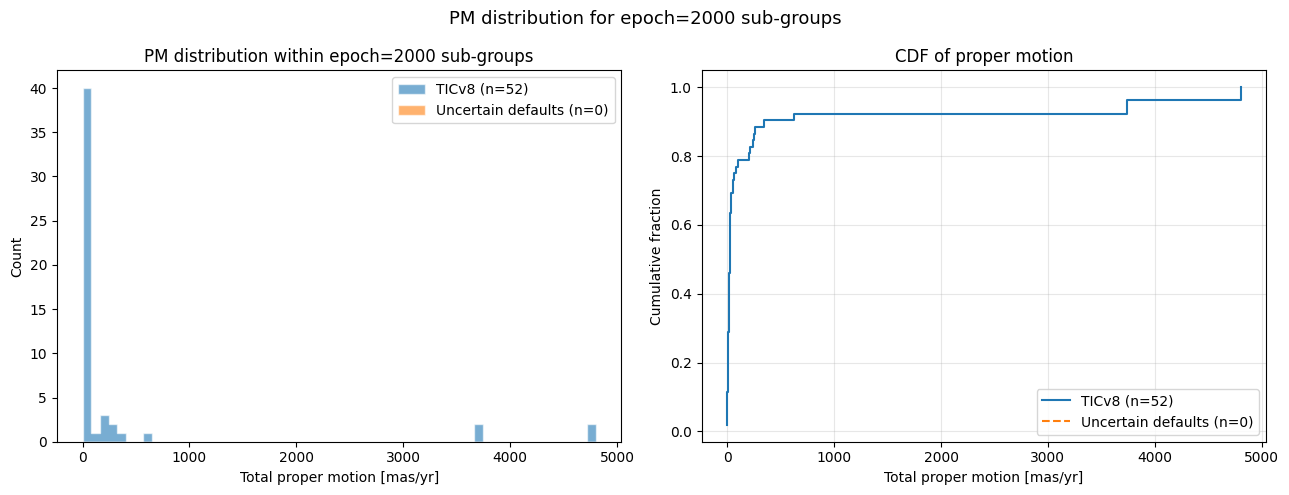


Proper motion summary (mas/yr):
                                      TICv8     Defaults
median                                 23.7          nan


/home/joshuadreier/Documents/CodingProjects/SemesterProjectEHG/.venv/lib64/python3.14/site-packages/numpy/_core/fromnumeric.py:3822: RuntimeWarning: Mean of empty slice
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/home/joshuadreier/Documents/CodingProjects/SemesterProjectEHG/.venv/lib64/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


IndexError: index -1 is out of bounds for axis 0 with size 0

In [45]:
pm_ticv8   = pm_arcsec[mask_ticv8]   * 1000   # back to mas/yr for display
pm_default = pm_arcsec[mask_default] * 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: PM histograms ───────────────────────────────────────────────────────
ax = axes[0]
clip = np.percentile(np.concatenate([pm_ticv8, pm_default]), 99)
bins = np.linspace(0, clip, 60)
ax.hist(pm_ticv8,   bins=bins, alpha=0.6, label=f"TICv8 (n={mask_ticv8.sum():,})",   histtype="stepfilled", edgecolor="white")
ax.hist(pm_default, bins=bins, alpha=0.6, label=f"Uncertain defaults (n={mask_default.sum():,})", histtype="stepfilled", edgecolor="white")
ax.set_xlabel("Total proper motion [mas/yr]")
ax.set_ylabel("Count")
ax.set_title("PM distribution within epoch=2000 sub-groups")
ax.legend()

# ── Right: CDF comparison ─────────────────────────────────────────────────────
ax2 = axes[1]
for label, data, ls in [
    (f"TICv8 (n={mask_ticv8.sum():,})",            np.sort(pm_ticv8),   "-"),
    (f"Uncertain defaults (n={mask_default.sum():,})", np.sort(pm_default), "--"),
]:
    frac = np.arange(1, len(data)+1) / len(data)
    ax2.step(data, frac, linestyle=ls, label=label, where="post")
ax2.set_xlabel("Total proper motion [mas/yr]")
ax2.set_ylabel("Cumulative fraction")
ax2.set_title("CDF of proper motion")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("PM distribution for epoch=2000 sub-groups", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nProper motion summary (mas/yr):")
print(f"{'':30s} {'TICv8':>12s} {'Defaults':>12s}")
print(f"{'median':30s} {np.median(pm_ticv8):>12.1f} {np.median(pm_default):>12.1f}")
print(f"{'p90':30s} {np.percentile(pm_ticv8, 90):>12.1f} {np.percentile(pm_default, 90):>12.1f}")
print(f"{'max':30s} {pm_ticv8.max():>12.1f} {pm_default.max():>12.1f}")
print(f"{'> 100 mas/yr':30s} {(pm_ticv8 > 100).sum():>12,d} {(pm_default > 100).sum():>12,d}")

### Threshold impact: what if default entries were actually epoch 2016?

For each uncertain default entry, compute the threshold both ways (Δt=0 as assigned, vs Δt=16 yr if the true epoch were 2016). The gap is the "missing" search cone we'd need to be correct.

In [ ]:
pm_d    = pm_arcsec[mask_default]
pmerr_d = pmerr_arcsec[mask_default]

# Threshold as currently computed (Δt = |2000 − 2000| = 0  →  only the floor)
thresh_assigned = allowed_angular_separation(pm_d, pmerr_d, np.full(mask_default.sum(), 2000.0),
                                             minimum=floor).to(u.arcsec).value

# Threshold if true epoch were 2016.0  (Δt = 16 yr)
thresh_if_2016  = allowed_angular_separation(pm_d, pmerr_d, np.full(mask_default.sum(), 2016.0),
                                             minimum=floor).to(u.arcsec).value

gap = thresh_if_2016 - thresh_assigned  # always ≥ 0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: scatter of assigned vs hypothetical threshold ──────────────────────
ax = axes[0]
ax.scatter(thresh_assigned, thresh_if_2016, s=6, alpha=0.5, c=pm_d*1000, cmap="plasma")
sc = ax.scatter(thresh_assigned, thresh_if_2016, s=6, alpha=0.5, c=pm_d*1000, cmap="plasma")
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Proper motion [mas/yr]")
lim_max = max(thresh_if_2016.max(), thresh_assigned.max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], "k--", lw=0.8, label="no change")
ax.set_xlabel('Assigned threshold (epoch=2000, Δt=0) ["]')
ax.set_ylabel('Threshold if epoch=2016 (Δt=16 yr) ["]')
ax.set_title("Assigned vs hypothetical 2016-epoch threshold")
ax.legend(fontsize=8)

# ── Right: histogram of the gap ──────────────────────────────────────────────
ax2 = axes[1]
ax2.hist(gap[gap > 0], bins=60, edgecolor="white")
ax2.set_xlabel('Extra search cone needed if epoch=2016 ["]')
ax2.set_ylabel("Count")
ax2.set_title(f"Threshold gap  (0 means PM=0, max gap = {gap.max():.1f}\")")
ax2.axvline(gap.max(), color="red", linestyle="--", lw=1.2,
            label=f"max {gap.max():.1f}\"  ({cat['hostname'][np.where(mask_default)[0][np.argmax(gap)]]})")
ax2.legend(fontsize=8)

plt.suptitle("Epoch uncertainty impact for uncertain-default entries", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Entries where gap > floor ({floor}):  {(gap > floor.to(u.arcsec).value).sum():,}"
      f"  (i.e. PM term would exceed the fixed floor if epoch were 2016)")

### High-PM uncertain defaults — the at-risk stars

These are the entries most likely to be missed by coordinate matching if the true epoch is Gaia-era rather than J2000. Listed in decreasing order of the gap between the two threshold estimates.

In [ ]:
import pandas as pd

default_idx = np.where(mask_default)[0]
order = np.argsort(gap)[::-1]
top_at_risk = 25

rows = []
for j in order[:top_at_risk]:
    i = default_idx[j]
    rows.append({
        "hostname":          str(cat["hostname"][i]),
        "epoch_rule":        str(cat["epoch_rule"][i]),
        "ra_reflink":        str(cat["ra_reflink"][i])[:60],
        "pm [mas/yr]":       round(float(pm_d[j]) * 1000, 1),
        'thresh @2000 ["]':  round(float(thresh_assigned[j]), 2),
        'thresh @2016 ["]':  round(float(thresh_if_2016[j]), 2),
        'gap ["]':           round(float(gap[j]), 2),
    })

df_risk = pd.DataFrame(rows)
print(f"Top {top_at_risk} uncertain-default entries ranked by epoch-2000 vs epoch-2016 threshold gap:")
print(df_risk.to_string(index=False))